In [0]:
# =============================================================================
# MVP de Engenharia de Dados — Ocorrências registradas em Sorocaba
# Notebook 03 — Três análises relacionadas às seis perguntas originais
#
# Todas as consultas analíticas usam apenas a Gold. Respostas, coberturas,
# limitações e conclusão são geradas com os valores observados na execução.
# =============================================================================

# Análise de Dados

O termo **ocorrência** significa uma natureza registrada em uma linha da
fonte, depois da deduplicação por linha integralmente idêntica. As contagens
não medem diretamente criminalidade real, risco individual ou causalidade.

As seis perguntas originais são: (1) bairros com mais ocorrências e sua
mudança; (2) sazonalidade por dia, mês e horário; (3) tipos por bairro/região;
(4) crescimento, queda ou estabilidade; (5) tipo de local versus ocorrência;
(6) correlação espacial entre tipos. As análises A1–A3 abaixo cobrem parte
desse objetivo; a autoavaliação explicita o que ficou sem resposta.

In [0]:
import html
import math

import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

CATALOG = "workspace"
SCHEMA = "sorocaba_seguranca"
ANO_INICIAL = 2022
ANO_FINAL = 2025
TOP_N_RANKING = 10
TOP_N_CRUZAMENTO = 5
NAO_INFORMADO = "NÃO INFORMADO"

TABELAS_NECESSARIAS = [
    "fato_ocorrencia",
    "dim_tempo",
    "dim_periodo_dia",
    "dim_natureza",
    "validacoes_qualidade",
]

spark.sql(f"USE CATALOG `{CATALOG}`")
spark.sql(f"USE SCHEMA `{SCHEMA}`")

ausentes = [
    tabela
    for tabela in TABELAS_NECESSARIAS
    if not spark.catalog.tableExists(f"{CATALOG}.{SCHEMA}.{tabela}")
]
if ausentes:
    raise RuntimeError(
        "Execute os notebooks 00, 01 e 02 antes da análise. "
        f"Tabelas ausentes: {', '.join(ausentes)}"
    )

erros_qualidade = spark.table("validacoes_qualidade").filter(
    F.col("status") == "ERRO"
).count()
if erros_qualidade:
    raise RuntimeError(
        f"A análise foi interrompida: há {erros_qualidade} validação(ões) de qualidade com ERRO."
    )

fato = spark.table("fato_ocorrencia")
total_fato = fato.agg(F.sum("qtd_ocorrencia").alias("total")).first()["total"] or 0
if total_fato == 0:
    raise RuntimeError("A fato está vazia; não há dados para responder às perguntas.")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "axes.grid": True,
})


def inteiro(valor):
    return f"{int(valor):,}".replace(",", ".")


def percentual(parte, total):
    return 100.0 * float(parte) / float(total) if total else 0.0


def texto_variacao(inicial, final):
    if inicial == 0:
        return "não é calculável porque o primeiro total é zero"
    variacao = 100.0 * (final - inicial) / inicial
    sentido = "aumento" if variacao > 0 else "queda" if variacao < 0 else "estabilidade"
    return f"{sentido} de {abs(variacao):.1f}%"


def mostrar_resposta(titulo, resposta, cobertura, limitacao, reconciliacao):
    displayHTML(f"""
    <div style="border-left:4px solid #2463a2;padding:10px 14px;margin:12px 0">
      <h3 style="margin:0 0 8px">{html.escape(titulo)}</h3>
      <p><strong>Resposta direta:</strong> {html.escape(resposta)}</p>
      <p><strong>Cobertura:</strong> {html.escape(cobertura)}</p>
      <p><strong>Limitação:</strong> {html.escape(limitacao)}</p>
      <p><strong>Reconciliação:</strong> {html.escape(reconciliacao)}</p>
    </div>
    """)


print(f"Fato disponível: {inteiro(total_fato)} ocorrências registradas")

Fato disponível: 65.325 ocorrências registradas


## Análise A1 — Como evoluiu o volume mensal e anual entre 2022 e 2025?

ano,total_ocorrencias
2022,14917
2023,16975
2024,16196
2025,16347


ano,mes,nome_mes,total_ocorrencias
2022,1,JANEIRO,1241
2022,2,FEVEREIRO,986
2022,3,MARÇO,1255
2022,4,ABRIL,1185
2022,5,MAIO,1302
2022,6,JUNHO,1174
2022,7,JULHO,1268
2022,8,AGOSTO,1348
2022,9,SETEMBRO,1212
2022,10,OUTUBRO,1326


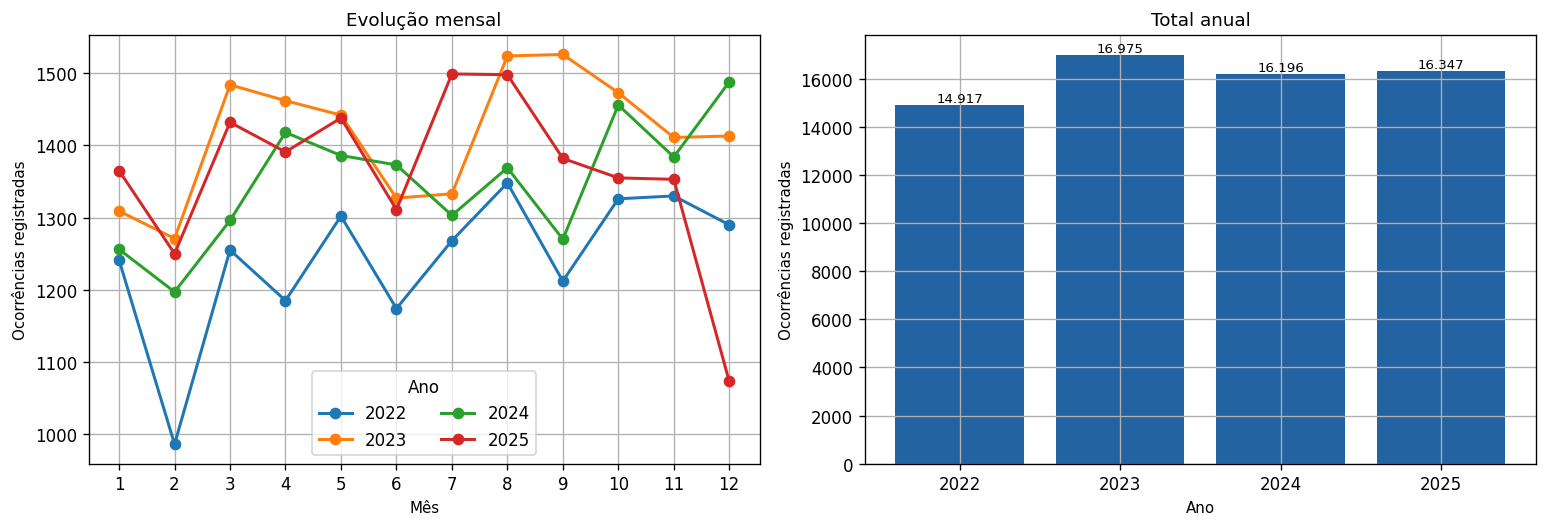

Resultado da análise A1 
 Resposta direta: Foram contabilizadas 64.435 ocorrências com data entre 2022 e 2025. O total passou de 14.917 em 2022 para 16.347 em 2025, com aumento de 9.6%. O maior total anual foi 16.975 em 2023; o pico mensal foi SETEMBRO de 2023, com 1.526. 
 Cobertura: 98.64% da fato entrou na janela; 299 registro(s) não têm data e 591 têm data fora dela. 
 Limitação: A variação descreve registros administrativos. Ela pode refletir cobertura, registro ou classificação e não demonstra mudança causal da criminalidade. 
 Reconciliação: 64.435 incluídos + 299 sem data + 591 fora da janela = 65.325 na fato.

In [0]:
mensal = spark.sql(f"""
    SELECT
        t.ano,
        t.mes,
        t.nome_mes,
        SUM(f.qtd_ocorrencia) AS total_ocorrencias
    FROM fato_ocorrencia f
    INNER JOIN dim_tempo t ON f.sk_tempo = t.sk_tempo
    WHERE t.ano BETWEEN {ANO_INICIAL} AND {ANO_FINAL}
    GROUP BY t.ano, t.mes, t.nome_mes
    ORDER BY t.ano, t.mes
""")

anual = mensal.groupBy("ano").agg(
    F.sum("total_ocorrencias").alias("total_ocorrencias")
).orderBy("ano")

display(anual)
display(mensal)

pdf_mensal = mensal.toPandas()
pdf_anual = anual.toPandas()

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
for ano, grupo in pdf_mensal.groupby("ano"):
    eixos[0].plot(
        grupo["mes"], grupo["total_ocorrencias"], marker="o", linewidth=1.8,
        label=str(int(ano)),
    )
eixos[0].set(title="Evolução mensal", xlabel="Mês", ylabel="Ocorrências registradas")
eixos[0].set_xticks(range(1, 13))
eixos[0].legend(title="Ano", ncols=2)
eixos[1].bar(pdf_anual["ano"].astype(str), pdf_anual["total_ocorrencias"], color="#2463a2")
eixos[1].set(title="Total anual", xlabel="Ano", ylabel="Ocorrências registradas")
for indice, valor in enumerate(pdf_anual["total_ocorrencias"]):
    eixos[1].text(indice, valor, inteiro(valor), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

total_com_data_periodo = int(mensal.agg(F.sum("total_ocorrencias")).first()[0] or 0)
if total_com_data_periodo == 0:
    raise RuntimeError(
        f"Não há ocorrências com data entre {ANO_INICIAL} e {ANO_FINAL}."
    )
sem_data = fato.filter(F.col("sk_tempo") == -1).agg(
    F.sum("qtd_ocorrencia")
).first()[0] or 0
fora_periodo = spark.sql(f"""
    SELECT COALESCE(SUM(f.qtd_ocorrencia), 0) AS total
    FROM fato_ocorrencia f
    INNER JOIN dim_tempo t ON f.sk_tempo = t.sk_tempo
    WHERE t.sk_tempo <> -1 AND (t.ano < {ANO_INICIAL} OR t.ano > {ANO_FINAL})
""").first()["total"]

if total_com_data_periodo + sem_data + fora_periodo != total_fato:
    raise AssertionError("A agregação temporal não reconcilia com a fato.")

anos_observados = {int(r["ano"]): int(r["total_ocorrencias"]) for r in anual.collect()}
primeiro = anos_observados.get(ANO_INICIAL, 0)
ultimo = anos_observados.get(ANO_FINAL, 0)
ano_max, total_max = max(anos_observados.items(), key=lambda item: item[1])
pico_mensal = mensal.orderBy(F.desc("total_ocorrencias"), "ano", "mes").first()

resposta_p1 = (
    f"Foram contabilizadas {inteiro(total_com_data_periodo)} ocorrências com data entre "
    f"{ANO_INICIAL} e {ANO_FINAL}. O total passou de {inteiro(primeiro)} em {ANO_INICIAL} "
    f"para {inteiro(ultimo)} em {ANO_FINAL}, com {texto_variacao(primeiro, ultimo)}. "
    f"O maior total anual foi {inteiro(total_max)} em {ano_max}; o pico mensal foi "
    f"{pico_mensal['nome_mes']} de {pico_mensal['ano']}, com "
    f"{inteiro(pico_mensal['total_ocorrencias'])}."
)
cobertura_p1 = (
    f"{percentual(total_com_data_periodo, total_fato):.2f}% da fato entrou na janela; "
    f"{inteiro(sem_data)} registro(s) não têm data e {inteiro(fora_periodo)} têm data fora dela."
)
limite_p1 = (
    "A variação descreve registros administrativos. Ela pode refletir cobertura, registro "
    "ou classificação e não demonstra mudança causal da criminalidade."
)
reconciliacao_p1 = (
    f"{inteiro(total_com_data_periodo)} incluídos + {inteiro(sem_data)} sem data + "
    f"{inteiro(fora_periodo)} fora da janela = {inteiro(total_fato)} na fato."
)
mostrar_resposta("Resultado da análise A1", resposta_p1, cobertura_p1, limite_p1, reconciliacao_p1)

## Análise A2 — Quais naturezas concentram maior volume e como variaram?

natureza_apurada,total_ocorrencias
FURTO - OUTROS,37053
LESÃO CORPORAL DOLOSA,7979
FURTO DE VEÍCULO,6518
ROUBO - OUTROS,5348
LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO,2848
ROUBO DE VEÍCULO,1313
TRÁFICO DE ENTORPECENTES,920
ESTUPRO DE VULNERÁVEL,688
HOMICÍDIO CULPOSO POR ACIDENTE DE TRÂNSITO,242
ESTUPRO,232


ano,natureza_apurada,total_ocorrencias
2022,FURTO - OUTROS,9101
2023,FURTO - OUTROS,9494
2024,FURTO - OUTROS,9120
2025,FURTO - OUTROS,9338
2022,FURTO DE VEÍCULO,1280
2023,FURTO DE VEÍCULO,1811
2024,FURTO DE VEÍCULO,1713
2025,FURTO DE VEÍCULO,1714
2022,LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO,600
2023,LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO,696


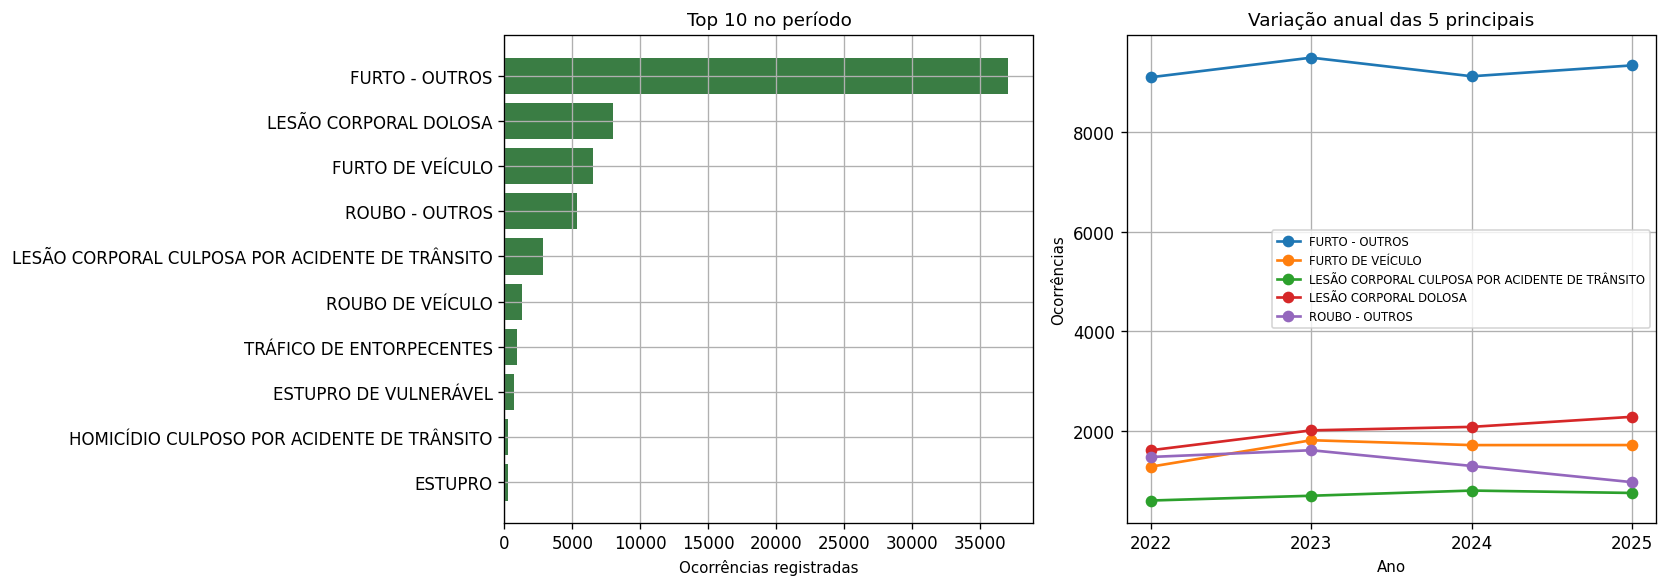

Resultado da análise A2 
 Resposta direta: As três naturezas classificadas com maior volume foram FURTO - OUTROS (37.053; 57.5%); LESÃO CORPORAL DOLOSA (7.979; 12.4%); FURTO DE VEÍCULO (6.518; 10.1%). A líder, FURTO - OUTROS, apresentou aumento de 2.6% entre 2022 e 2025. A tabela e o gráfico exibem a trajetória anual das 5 principais. 
 Cobertura: O ranking reconcilia 64.435 registros na janela; 0 (0.00%) não têm natureza classificada. 
 Limitação: Frequência de uma categoria depende da classificação administrativa e de eventuais mudanças de preenchimento; não equivale a gravidade nem a risco. 
 Reconciliação: A soma de todas as naturezas é 64.435, igual ao total temporal incluído na análise A1.

In [0]:
ranking_natureza = spark.sql(f"""
    SELECT
        n.natureza_apurada,
        SUM(f.qtd_ocorrencia) AS total_ocorrencias
    FROM fato_ocorrencia f
    INNER JOIN dim_tempo t ON f.sk_tempo = t.sk_tempo
    INNER JOIN dim_natureza n ON f.sk_natureza = n.sk_natureza
    WHERE t.ano BETWEEN {ANO_INICIAL} AND {ANO_FINAL}
    GROUP BY n.natureza_apurada
    ORDER BY total_ocorrencias DESC, n.natureza_apurada
""")

top_classificadas = ranking_natureza.filter(
    F.col("natureza_apurada") != NAO_INFORMADO
).orderBy(F.desc("total_ocorrencias"), "natureza_apurada").limit(TOP_N_CRUZAMENTO)

naturezas_top = [r["natureza_apurada"] for r in top_classificadas.collect()]
if not naturezas_top:
    raise RuntimeError("Nenhuma natureza classificada foi encontrada para as análises A2 e A3.")

# A view temporária contém somente categorias derivadas da consulta Gold acima.
top_classificadas.select("natureza_apurada").createOrReplaceTempView("top_naturezas")
evolucao_top = spark.sql(f"""
    SELECT
        t.ano,
        n.natureza_apurada,
        SUM(f.qtd_ocorrencia) AS total_ocorrencias
    FROM fato_ocorrencia f
    INNER JOIN dim_tempo t ON f.sk_tempo = t.sk_tempo
    INNER JOIN dim_natureza n ON f.sk_natureza = n.sk_natureza
    INNER JOIN top_naturezas top ON n.natureza_apurada = top.natureza_apurada
    WHERE t.ano BETWEEN {ANO_INICIAL} AND {ANO_FINAL}
    GROUP BY t.ano, n.natureza_apurada
    ORDER BY n.natureza_apurada, t.ano
""")

display(ranking_natureza.limit(TOP_N_RANKING))
display(evolucao_top)

pdf_ranking = ranking_natureza.limit(TOP_N_RANKING).toPandas().sort_values(
    "total_ocorrencias", ascending=True
)
pdf_evolucao = evolucao_top.toPandas()

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].barh(
    pdf_ranking["natureza_apurada"], pdf_ranking["total_ocorrencias"], color="#3a7d44"
)
eixos[0].set(title=f"Top {TOP_N_RANKING} no período", xlabel="Ocorrências registradas")
for natureza, grupo in pdf_evolucao.groupby("natureza_apurada"):
    eixos[1].plot(
        grupo["ano"], grupo["total_ocorrencias"], marker="o", linewidth=1.6,
        label=natureza,
    )
eixos[1].set(title=f"Variação anual das {TOP_N_CRUZAMENTO} principais", xlabel="Ano", ylabel="Ocorrências")
eixos[1].set_xticks(range(ANO_INICIAL, ANO_FINAL + 1))
eixos[1].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

total_ranking = int(ranking_natureza.agg(F.sum("total_ocorrencias")).first()[0] or 0)
if total_ranking != total_com_data_periodo:
    raise AssertionError("O ranking de naturezas não reconcilia com a análise temporal.")

linhas_ranking = ranking_natureza.collect()
top_conhecidas = [r for r in linhas_ranking if r["natureza_apurada"] != NAO_INFORMADO]
desconhecidas = next(
    (int(r["total_ocorrencias"]) for r in linhas_ranking if r["natureza_apurada"] == NAO_INFORMADO),
    0,
)
top_tres = top_conhecidas[:3]
lista_top = "; ".join(
    f"{r['natureza_apurada']} ({inteiro(r['total_ocorrencias'])}; "
    f"{percentual(r['total_ocorrencias'], total_ranking):.1f}%)"
    for r in top_tres
)

lider = top_conhecidas[0]
lider_anos = {
    int(r["ano"]): int(r["total_ocorrencias"])
    for r in evolucao_top.filter(
        F.col("natureza_apurada") == lider["natureza_apurada"]
    ).collect()
}
variacao_lider = texto_variacao(
    lider_anos.get(ANO_INICIAL, 0), lider_anos.get(ANO_FINAL, 0)
)
resposta_p2 = (
    f"As três naturezas classificadas com maior volume foram {lista_top}. "
    f"A líder, {lider['natureza_apurada']}, apresentou {variacao_lider} entre "
    f"{ANO_INICIAL} e {ANO_FINAL}. A tabela e o gráfico exibem a trajetória anual "
    f"das {TOP_N_CRUZAMENTO} principais."
)
cobertura_p2 = (
    f"O ranking reconcilia {inteiro(total_ranking)} registros na janela; "
    f"{inteiro(desconhecidas)} ({percentual(desconhecidas, total_ranking):.2f}%) "
    "não têm natureza classificada."
)
limite_p2 = (
    "Frequência de uma categoria depende da classificação administrativa e de eventuais "
    "mudanças de preenchimento; não equivale a gravidade nem a risco."
)
reconciliacao_p2 = (
    f"A soma de todas as naturezas é {inteiro(total_ranking)}, igual ao total temporal "
    "incluído na análise A1."
)
mostrar_resposta("Resultado da análise A2", resposta_p2, cobertura_p2, limite_p2, reconciliacao_p2)

## Análise A3 — Como as principais naturezas se distribuem por dia e período?

natureza_apurada,dia_semana_num,dia_semana_nome,periodo_dia,total_ocorrencias
FURTO - OUTROS,1,DOMINGO,HORA INCERTA,149
FURTO - OUTROS,1,DOMINGO,MADRUGADA,1685
FURTO - OUTROS,1,DOMINGO,MANHÃ,748
FURTO - OUTROS,1,DOMINGO,NOITE,1050
FURTO - OUTROS,1,DOMINGO,NÃO INFORMADO,105
FURTO - OUTROS,1,DOMINGO,TARDE,838
FURTO - OUTROS,2,SEGUNDA-FEIRA,HORA INCERTA,234
FURTO - OUTROS,2,SEGUNDA-FEIRA,MADRUGADA,1717
FURTO - OUTROS,2,SEGUNDA-FEIRA,MANHÃ,1436
FURTO - OUTROS,2,SEGUNDA-FEIRA,NOITE,835


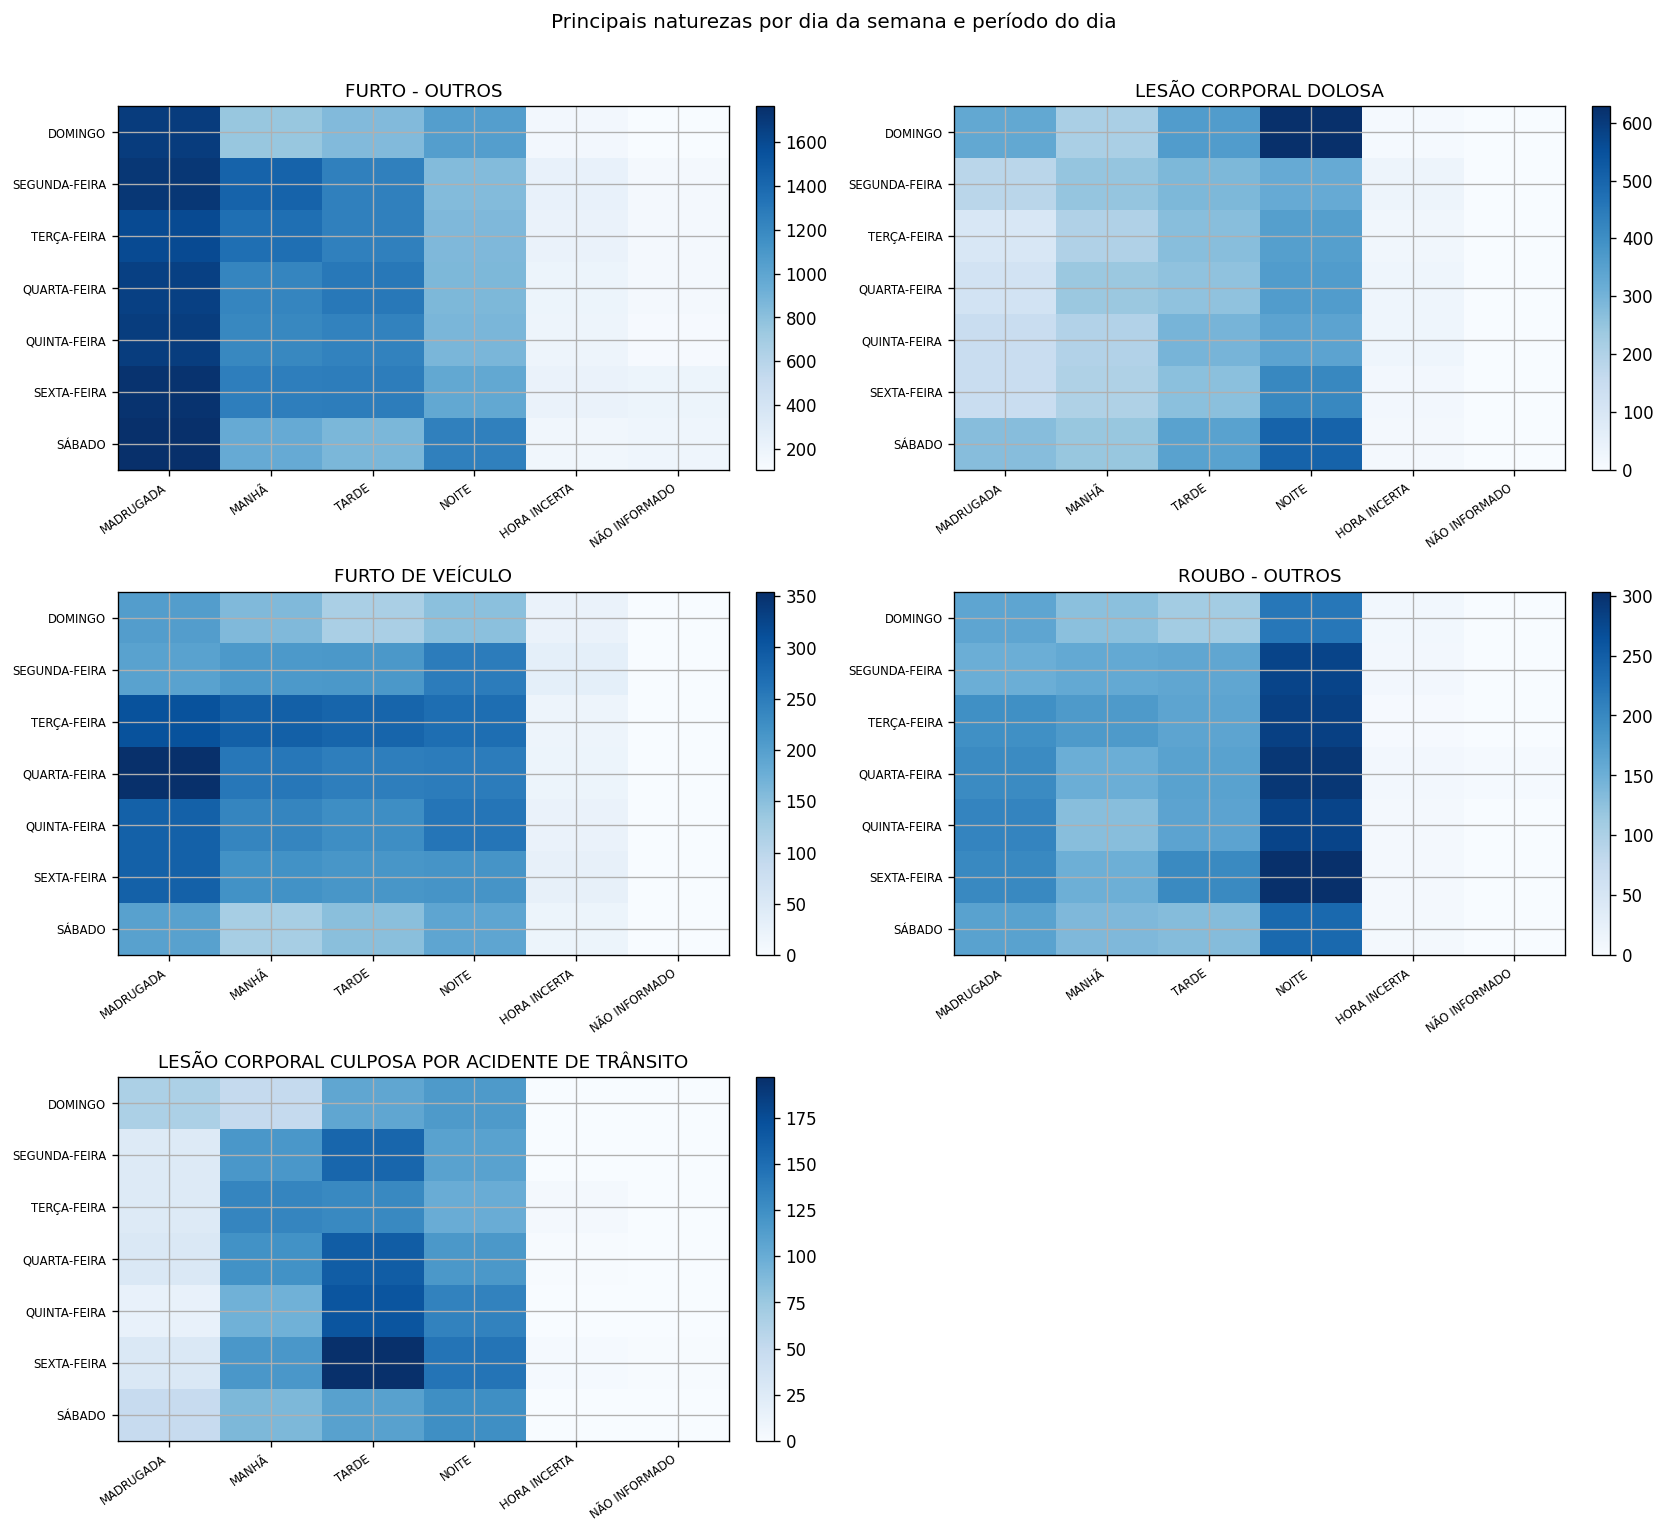

Resultado da análise A3 
 Resposta direta: As combinações com maior volume para cada uma das naturezas principais foram: FURTO - OUTROS: SÁBADO / MADRUGADA (1.763); LESÃO CORPORAL DOLOSA: DOMINGO / NOITE (628); FURTO DE VEÍCULO: QUARTA-FEIRA / MADRUGADA (354); ROUBO - OUTROS: SEXTA-FEIRA / NOITE (303); LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO: SEXTA-FEIRA / TARDE (197). Os mapas de calor mostram também a distribuição completa, sem ocultar as demais combinações. 
 Cobertura: Foram cruzados 59.746 registros das 5 principais naturezas; 1.025 (1.72%) têm período não informado. 
 Limitação: A ausência de data impede entrada na janela; período pode vir da fonte ou ser derivado da hora. Picos descritivos não demonstram causalidade nem orientam policiamento. 
 Reconciliação: A soma da matriz (59.746) é igual ao total anual das mesmas 5 naturezas (59.746).

In [0]:
distribuicao = spark.sql(f"""
    SELECT
        n.natureza_apurada,
        t.dia_semana_num,
        t.dia_semana_nome,
        p.periodo_dia,
        SUM(f.qtd_ocorrencia) AS total_ocorrencias
    FROM fato_ocorrencia f
    INNER JOIN dim_tempo t ON f.sk_tempo = t.sk_tempo
    INNER JOIN dim_periodo_dia p ON f.sk_periodo_dia = p.sk_periodo_dia
    INNER JOIN dim_natureza n ON f.sk_natureza = n.sk_natureza
    INNER JOIN top_naturezas top ON n.natureza_apurada = top.natureza_apurada
    WHERE t.ano BETWEEN {ANO_INICIAL} AND {ANO_FINAL}
    GROUP BY n.natureza_apurada, t.dia_semana_num, t.dia_semana_nome, p.periodo_dia
    ORDER BY n.natureza_apurada, t.dia_semana_num, p.periodo_dia
""")

display(distribuicao)
pdf_distribuicao = distribuicao.toPandas()

ordem_dias = [
    "DOMINGO", "SEGUNDA-FEIRA", "TERÇA-FEIRA", "QUARTA-FEIRA",
    "QUINTA-FEIRA", "SEXTA-FEIRA", "SÁBADO",
]
ordem_periodos = ["MADRUGADA", "MANHÃ", "TARDE", "NOITE", "HORA INCERTA", NAO_INFORMADO]

n_colunas = 2
n_linhas = math.ceil(len(naturezas_top) / n_colunas)
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(14, 4.2 * n_linhas), squeeze=False)
for eixo, natureza in zip(eixos.flat, naturezas_top):
    recorte = pdf_distribuicao[pdf_distribuicao["natureza_apurada"] == natureza]
    matriz = recorte.pivot_table(
        index="dia_semana_nome",
        columns="periodo_dia",
        values="total_ocorrencias",
        aggfunc="sum",
        fill_value=0,
    ).reindex(index=ordem_dias, columns=ordem_periodos, fill_value=0)
    imagem = eixo.imshow(matriz.values, aspect="auto", cmap="Blues")
    eixo.set_title(natureza)
    eixo.set_xticks(range(len(ordem_periodos)), ordem_periodos, rotation=35, ha="right", fontsize=7)
    eixo.set_yticks(range(len(ordem_dias)), ordem_dias, fontsize=7)
    fig.colorbar(imagem, ax=eixo, fraction=0.046, pad=0.04)
for eixo in eixos.flat[len(naturezas_top):]:
    eixo.axis("off")
fig.suptitle("Principais naturezas por dia da semana e período do dia", y=1.01)
plt.tight_layout()
plt.show()

total_distribuicao = int(distribuicao.agg(F.sum("total_ocorrencias")).first()[0] or 0)
total_top_esperado = int(evolucao_top.agg(F.sum("total_ocorrencias")).first()[0] or 0)
if total_distribuicao != total_top_esperado:
    raise AssertionError("A distribuição por dia/período não reconcilia com as naturezas selecionadas.")

picos = (
    distribuicao
    .withColumn(
        "posicao",
        F.row_number().over(
            Window.partitionBy("natureza_apurada")
            .orderBy(F.desc("total_ocorrencias"), "dia_semana_num", "periodo_dia")
        ),
    )
    .filter(F.col("posicao") == 1)
    .orderBy(F.desc("total_ocorrencias"))
    .collect()
)
descricao_picos = "; ".join(
    f"{r['natureza_apurada']}: {r['dia_semana_nome']} / {r['periodo_dia']} "
    f"({inteiro(r['total_ocorrencias'])})"
    for r in picos
)

sem_periodo_top = int(
    distribuicao.filter(F.col("periodo_dia") == NAO_INFORMADO)
    .agg(F.sum("total_ocorrencias")).first()[0] or 0
)
resposta_p3 = (
    "As combinações com maior volume para cada uma das naturezas principais foram: "
    f"{descricao_picos}. Os mapas de calor mostram também a distribuição completa, "
    "sem ocultar as demais combinações."
)
cobertura_p3 = (
    f"Foram cruzados {inteiro(total_distribuicao)} registros das "
    f"{len(naturezas_top)} principais naturezas; {inteiro(sem_periodo_top)} "
    f"({percentual(sem_periodo_top, total_distribuicao):.2f}%) têm período não informado."
)
limite_p3 = (
    "A ausência de data impede entrada na janela; período pode vir da fonte ou ser derivado "
    "da hora. Picos descritivos não demonstram causalidade nem orientam policiamento."
)
reconciliacao_p3 = (
    f"A soma da matriz ({inteiro(total_distribuicao)}) é igual ao total anual das mesmas "
    f"{len(naturezas_top)} naturezas ({inteiro(total_top_esperado)})."
)
mostrar_resposta("Resultado da análise A3", resposta_p3, cobertura_p3, limite_p3, reconciliacao_p3)

## Conclusão geral e autoavaliação baseada na execução

A1 responde descritivamente à pergunta original 4; A1 e A3 cobrem parte da
pergunta 2. As perguntas originais 1 (bairros), 3 (tipos por bairro/região),
5 (tipo de local versus ocorrência) e 6 (correlação espacial) não foram
respondidas nesta entrega. A1–A3 não contêm análise por hora nem demonstram
repetição sazonal.

In [0]:
conclusao = (
    f"O pipeline tornou comparáveis {inteiro(total_com_data_periodo)} registros com data "
    f"entre {ANO_INICIAL} e {ANO_FINAL}. Nesse recorte, o volume anual teve "
    f"{texto_variacao(primeiro, ultimo)} do primeiro para o último ano e atingiu seu "
    f"maior valor em {ano_max}. As categorias de maior frequência foram "
    f"{', '.join(r['natureza_apurada'] for r in top_tres)}, e o cruzamento temporal "
    f"das {len(naturezas_top)} principais foi reconciliado integralmente com a Gold. "
    "As três análises foram concluídas, mas o objetivo original de seis perguntas "
    "foi atingido apenas em parte. As ausências explicitadas nas coberturas impedem "
    "interpretar as "
    "frequências como total real de crimes, relação causal ou recomendação operacional."
)

autoavaliacao = (
    "Pergunta original 1: não respondida, pois não houve análise por bairro. "
    "Pergunta 2: parcialmente respondida, com mês, dia da semana e período, "
    "sem análise por hora ou conclusão de sazonalidade. Pergunta 3: não respondida, "
    "pois as naturezas foram agrupadas apenas no município. Pergunta 4: respondida "
    "descritivamente pela variação anual de A1. Pergunta 5: não respondida, pois "
    "não houve cruzamento com tipo de local. Pergunta 6: não respondida, pois "
    "não foi calculada correlação espacial. As análises A1–A3 têm tabelas, gráficos, "
    "cobertura e reconciliação. "
    "As principais dificuldades técnicas foram conciliar quatro schemas, ler XLSX grandes "
    "com recursos limitados e preservar o grão sem eliminar BOs legítimos. O uso de leitura "
    "em lotes, hash integral e chaves determinísticas resolveu essas dificuldades. Permanecem "
    "como limitações uma única fonte, ausência de denominador populacional, dependência do "
    "preenchimento administrativo e falta de validação externa de cada registro. Somente "
    "depois de concluir as evidências deste MVP faz sentido avaliar novas fontes ou anos."
)

displayHTML(f"""
<div style="border:1px solid #bbb;padding:14px;margin-top:14px">
  <h2>Conclusão geral</h2>
  <p>{html.escape(conclusao)}</p>
  <h2>Autoavaliação da execução</h2>
  <p>{html.escape(autoavaliacao)}</p>
</div>
""")

print("Três análises concluídas; atingimento parcial das seis perguntas originais.")
dbutils.notebook.exit("ok")